In [1]:
%pip install pandas requests scipy matplotlib numpy statsmodels scikit-learn 


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import re
import requests
import scipy as sp
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import csv
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [3]:
data = pd.read_csv('NADAC-EphMra.csv')

print(data.head())
print(data.info())
print(f"Missing values:\n{data.isnull().sum()}")

  Generic Name     Product                                     Company  \
0   adalimumab  adalimumab                                  sandoz inc   
1   adalimumab  adalimumab                                  sandoz inc   
2   adalimumab     cyltezo  boehringer ingelheim pharmaceuticals, inc.   
3   adalimumab      humira                                 abbvie inc.   
4   adalimumab      humira                                 abbvie inc.   

         ndc11                                    ndc_description  \
0  61314032720               ADALIMUMAB-ADAZ(CF) PEN 40 MG/0.4 ML   
1  61314032720               ADALIMUMAB-ADAZ(CF) PEN 40 MG/0.4 ML   
2    597037597                       CYLTEZO(CF) PEN 40 MG/0.8 ML   
3     74012402                        HUMIRA(CF) PEN 80 MG/0.8 ML   
4     74012403  HUMIRA(CF) PEN CROHN'S-UC-HS STARTER 80 MG/0.8 ML   

  pricing_unit        2025        2024      2023  2022            Technology  \
0           ML  1592.35758  1590.28426       NaN   NaN  Reco

In [4]:
# Parse NDC description to extract dosage strength and dosage form
def extract_mg_from_description(description):
    """Extract mg strength from NDC description (for example, '40 MG/0.4 ML' -> 40)."""
    if pd.isna(description):
        return np.nan

    match = re.search(r'(\d+(?:\.\d+)?)\s*MG', str(description), re.IGNORECASE)
    if match:
        return float(match.group(1))
    return np.nan


def extract_dosage_form(description):
    """
    Normalize dosage form from NDC description.
    Rules:
    - ONE-PRESS -> PEN
    - AUTOINJECT / AUTOINJECTOR -> AUTOINJECTOR
    - SYRING / SYRINGE -> SYRINGE
    - ON-BODY and unmatched descriptions -> OTHER
    """
    if pd.isna(description):
        return 'OTHER'

    text = str(description).upper()

    if re.search(r'\bONE[\s-]?PRESS\b', text):
        return 'PEN'
    if re.search(r'\bAUTOINJECT(?:OR)?\b', text):
        return 'AUTOINJECTOR'
    if re.search(r'\bPEN\b', text):
        return 'PEN'
    if re.search(r'\bSYRING(?:E)?\b', text):
        return 'SYRINGE'
    if re.search(r'\bVIAL\b', text):
        return 'VIAL'
    if re.search(r'\bON[\s-]?BODY\b', text):
        return 'OTHER'

    return 'OTHER'


for year in ['2025', '2024', '2023', '2022']:
    data[year] = pd.to_numeric(data[year], errors='coerce')

data['mg_per_unit'] = data['ndc_description'].apply(extract_mg_from_description)
data['dosage_form'] = data['ndc_description'].apply(extract_dosage_form)

print('Dosage form counts from ndc_description (normalized):')
print(data['dosage_form'].value_counts(dropna=False))

# Normalize prices to price per mg only when mg_per_unit is valid and > 0
valid_mg = data['mg_per_unit'] > 0
for year in ['2025', '2024', '2023', '2022']:
    data[f'{year}_per_mg'] = np.where(valid_mg, data[year] / data['mg_per_unit'], np.nan)

print('\nSample of normalized prices:')
print(data[['ndc_description', 'dosage_form', 'mg_per_unit', '2025', '2025_per_mg']].head(10))

data_clean = data.dropna(subset=['mg_per_unit']).copy()
print(f"\nRows after mg extraction: {len(data_clean)} (from {len(data)})")
print(f"Rows removed (no mg found): {len(data) - len(data_clean)}")

Dosage form counts from ndc_description (normalized):
dosage_form
PEN             37
SYRINGE         25
AUTOINJECTOR    14
OTHER            9
VIAL             5
Name: count, dtype: int64

Sample of normalized prices:
                                     ndc_description dosage_form  mg_per_unit  \
0               ADALIMUMAB-ADAZ(CF) PEN 40 MG/0.4 ML         PEN         40.0   
1               ADALIMUMAB-ADAZ(CF) PEN 40 MG/0.4 ML         PEN         40.0   
2                       CYLTEZO(CF) PEN 40 MG/0.8 ML         PEN         40.0   
3                        HUMIRA(CF) PEN 80 MG/0.8 ML         PEN         80.0   
4  HUMIRA(CF) PEN CROHN'S-UC-HS STARTER 80 MG/0.8 ML         PEN         80.0   
5                    HUMIRA(CF) 40 MG/0.4 ML SYRINGE     SYRINGE         40.0   
6                        HUMIRA(CF) PEN 40 MG/0.4 ML         PEN         40.0   
7                    HUMIRA(CF) 20 MG/0.2 ML SYRINGE     SYRINGE         20.0   
8  HUMIRA(CF) PEN PS-UV-ADOL HS START 80 MG/0.8 M...  

In [5]:
# MODEL 1: Distribution-based view (2025 only)
model1_long = data_clean[
    ['ndc11', 'Corrected EphMRA Code', 'dosage_form', '2025_per_mg']
].copy()

model1_long = model1_long.rename(columns={'2025_per_mg': 'price_per_mg'})
model1_long = model1_long.dropna(subset=['price_per_mg', 'Corrected EphMRA Code'])
model1_long = model1_long[model1_long['price_per_mg'] > 0].copy()
model1_long['year'] = '2025_per_mg'

print(f"\nModel 1 observations (2025 only): {len(model1_long)}")
print('Dosage forms observed in model_1:', sorted(model1_long['dosage_form'].unique().tolist()))

model1_distribution = model1_long.groupby(['Corrected EphMRA Code', 'dosage_form'])['price_per_mg'].agg(
    n='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max',
    p25=lambda s: s.quantile(0.25),
    p75=lambda s: s.quantile(0.75)
).reset_index()

model1_distribution = model1_distribution.sort_values(['Corrected EphMRA Code', 'dosage_form'])

print('\n=== MODEL 1: 2025 Price/mg Distribution by EphMRA + Dosage Form ===')
print(model1_distribution.round(4).to_string(index=False))

overall_by_form = model1_long.groupby('dosage_form')['price_per_mg'].agg(
    n='count', mean='mean', median='median', min='min', max='max',
    p25=lambda s: s.quantile(0.25),
    p75=lambda s: s.quantile(0.75)
).reset_index()

print('\nOverall 2025 distribution by dosage form:')
print(overall_by_form.round(4).to_string(index=False))


Model 1 observations (2025 only): 90
Dosage forms observed in model_1: ['AUTOINJECTOR', 'OTHER', 'PEN', 'SYRINGE', 'VIAL']

=== MODEL 1: 2025 Price/mg Distribution by EphMRA + Dosage Form ===
                           Corrected EphMRA Code  dosage_form  n      mean    median      std       min       max       p25       p75
                        C10A4 (PCSK9 Inhibitors)        OTHER  2    1.9744    1.9744   0.0000    1.9744    1.9744    1.9744    1.9744
                        C10A4 (PCSK9 Inhibitors)          PEN  2    2.5058    2.5058   1.1807    1.6710    3.3407    2.0884    2.9233
                        C10A4 (PCSK9 Inhibitors)      SYRINGE  2    1.9695    1.9695   0.0000    1.9695    1.9695    1.9695    1.9695
L1G1 (Monoclonal Antibody Antineoplastics, CD20)          PEN  1 1132.3759 1132.3759      NaN 1132.3759 1132.3759 1132.3759 1132.3759
                         L4B (Anti-TNF Products)        OTHER  1   28.9167   28.9167      NaN   28.9167   28.9167   28.9167   28.9167
   

In [6]:
# Quick view for model_1 coverage by dosage form
if 'model1_long' in globals() and len(model1_long) > 0:
    print('Model_1 dosage forms:', sorted(model1_long['dosage_form'].unique().tolist()))
    print(model1_long['dosage_form'].value_counts().to_string())

Model_1 dosage forms: ['AUTOINJECTOR', 'OTHER', 'PEN', 'SYRINGE', 'VIAL']
dosage_form
PEN             37
SYRINGE         25
AUTOINJECTOR    14
OTHER            9
VIAL             5


In [7]:
# MODEL 1 significance testing (2025-only): EphMRA + dosage_form vs price
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind, mannwhitneyu

sig_df = model1_long[['Corrected EphMRA Code', 'dosage_form', 'price_per_mg']].dropna().copy()
sig_df = sig_df[sig_df['price_per_mg'] > 0].copy()
sig_df['log_price'] = np.log(sig_df['price_per_mg'])

# Use an explicit code token for L4B
sig_df['is_l4b'] = sig_df['Corrected EphMRA Code'].str.contains(r'\bL4B\b', case=False, regex=True, na=False)

print(f"Rows used in significance testing: {len(sig_df)}")
print(f"L4B rows: {sig_df['is_l4b'].sum()}")
print('Dosage-form counts in test set:')
print(sig_df['dosage_form'].value_counts().to_string())
print('\nCell counts (is_l4b x dosage_form):')
print(pd.crosstab(sig_df['is_l4b'], sig_df['dosage_form']).to_string())

anova_model = smf.ols('log_price ~ C(is_l4b) * C(dosage_form)', data=sig_df).fit()

# Type III first (preferred for unbalanced design with interaction)
anova_type3 = sm.stats.anova_lm(anova_model, typ=3)
resid_ss_3 = anova_type3.loc['Residual', 'sum_sq']
anova_type3['partial_eta_sq'] = anova_type3['sum_sq'] / (anova_type3['sum_sq'] + resid_ss_3)

print('\n=== Factorial ANOVA (Type III) ===')
print(anova_type3.round(6).to_string())

# Type II below Type III for side-by-side interpretation
anova_type2 = sm.stats.anova_lm(anova_model, typ=2)
resid_ss_2 = anova_type2.loc['Residual', 'sum_sq']
anova_type2['partial_eta_sq'] = anova_type2['sum_sq'] / (anova_type2['sum_sq'] + resid_ss_2)

print('\n=== Factorial ANOVA (Type II) ===')
print(anova_type2.round(6).to_string())

# Planned contrast: L4B + PEN vs all others
contrast_mask = sig_df['is_l4b'] & (sig_df['dosage_form'] == 'PEN')
g1 = sig_df.loc[contrast_mask, 'log_price']
g2 = sig_df.loc[~contrast_mask, 'log_price']

print(f"\nPlanned contrast sizes -> L4B+PEN: n={len(g1)}, Others: n={len(g2)}")
if len(g1) >= 2 and len(g2) >= 2:
    t_stat, p_t = ttest_ind(g1, g2, equal_var=False, nan_policy='omit')
    u_stat, p_u = mannwhitneyu(g1, g2, alternative='two-sided')

    # Cohen's d on log-price for effect size
    n1, n2 = len(g1), len(g2)
    s1, s2 = g1.std(ddof=1), g2.std(ddof=1)
    pooled_sd = np.sqrt(((n1 - 1) * (s1 ** 2) + (n2 - 1) * (s2 ** 2)) / (n1 + n2 - 2))
    cohens_d = (g1.mean() - g2.mean()) / pooled_sd if pooled_sd > 0 else np.nan

    print(f"Welch t-test p-value: {p_t:.6g} (t={t_stat:.4f})")
    print(f"Mann-Whitney p-value: {p_u:.6g} (U={u_stat:.4f})")
    print(f"Cohen's d (log-price): {cohens_d:.4f}")
else:
    print('Not enough points for planned contrast tests.')

Rows used in significance testing: 90
L4B rows: 26
Dosage-form counts in test set:
dosage_form
PEN             37
SYRINGE         25
AUTOINJECTOR    14
OTHER            9
VIAL             5

Cell counts (is_l4b x dosage_form):


dosage_form  AUTOINJECTOR  OTHER  PEN  SYRINGE  VIAL
is_l4b                                              
False                  14      8   20       20     2
True                    0      1   17        5     3

=== Factorial ANOVA (Type III) ===
                              sum_sq    df          F    PR(>F)  partial_eta_sq
Intercept                  89.705607   1.0  43.408919  0.000000        0.348921
C(is_l4b)                   4.816802   1.0   2.330871  0.130726        0.027971
C(dosage_form)              8.480218   4.0   1.025903  0.399019        0.048219
C(is_l4b):C(dosage_form)   24.570810   4.0   2.972479  0.024109        0.128000
Residual                  167.388508  81.0        NaN       NaN        0.500000

=== Factorial ANOVA (Type II) ===
                              sum_sq    df         F    PR(>F)  partial_eta_sq
C(is_l4b)                  -0.000000   1.0 -0.000000  1.000000       -0.000000
C(dosage_form)             20.454728   4.0  2.474532  0.050743        0.108893


In [8]:
# MODEL 1B: Full group-wise ANOVA across EphMRA + dosage form
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

group_anova_df = model1_long[['Corrected EphMRA Code', 'dosage_form', 'price_per_mg']].dropna().copy()
group_anova_df = group_anova_df[group_anova_df['price_per_mg'] > 0].copy()
group_anova_df['log_price'] = np.log(group_anova_df['price_per_mg'])
group_anova_df['ephmra_dosage_group'] = (
    group_anova_df['Corrected EphMRA Code'] + ' | ' + group_anova_df['dosage_form']
)

group_counts = group_anova_df['ephmra_dosage_group'].value_counts().sort_index()
print('\n=== MODEL 1B: Group counts (EphMRA | dosage form) ===')
print(group_counts.to_string())

# Keep groups with at least 2 observations for stable variance estimation.
valid_groups = group_counts[group_counts >= 2].index
group_anova_df = group_anova_df[group_anova_df['ephmra_dosage_group'].isin(valid_groups)].copy()

if group_anova_df['ephmra_dosage_group'].nunique() < 2:
    print('\nNot enough EphMRA+dosage groups with n>=2 to run full group-wise ANOVA.')
else:
    full_group_model = smf.ols('log_price ~ C(ephmra_dosage_group)', data=group_anova_df).fit()
    full_group_anova = sm.stats.anova_lm(full_group_model, typ=2)
    resid_ss = full_group_anova.loc['Residual', 'sum_sq']
    full_group_anova['partial_eta_sq'] = full_group_anova['sum_sq'] / (full_group_anova['sum_sq'] + resid_ss)

    print('\n=== MODEL 1B: One-way ANOVA on log(price) by EphMRA+dosage group ===')
    print(full_group_anova.round(6).to_string())

    # Planned-contrast style analysis for every group: group vs all others.
    contrast_rows = []
    for group_label in sorted(group_anova_df['ephmra_dosage_group'].unique().tolist()):
        g = group_anova_df.loc[group_anova_df['ephmra_dosage_group'] == group_label, 'log_price']
        rest = group_anova_df.loc[group_anova_df['ephmra_dosage_group'] != group_label, 'log_price']

        if len(g) >= 2 and len(rest) >= 2:
            t_stat, p_t = ttest_ind(g, rest, equal_var=False, nan_policy='omit')
            u_stat, p_u = mannwhitneyu(g, rest, alternative='two-sided')

            n1, n2 = len(g), len(rest)
            s1, s2 = g.std(ddof=1), rest.std(ddof=1)
            pooled_sd = np.sqrt(((n1 - 1) * (s1 ** 2) + (n2 - 1) * (s2 ** 2)) / (n1 + n2 - 2))
            cohens_d = (g.mean() - rest.mean()) / pooled_sd if pooled_sd > 0 else np.nan

            contrast_rows.append({
                'group': group_label,
                'n_group': n1,
                'n_rest': n2,
                'mean_log_group': g.mean(),
                'mean_log_rest': rest.mean(),
                'diff_log': g.mean() - rest.mean(),
                'cohens_d': cohens_d,
                'welch_t': t_stat,
                'welch_p': p_t,
                'mwu_u': u_stat,
                'mwu_p': p_u,
            })

    if len(contrast_rows) == 0:
        print('\nNot enough data for group-vs-rest contrasts.')
    else:
        contrast_df = pd.DataFrame(contrast_rows)

        # Holm correction controls family-wise error rate across all tested groups.
        contrast_df['welch_p_holm'] = multipletests(contrast_df['welch_p'], method='holm')[1]
        contrast_df['welch_sig_holm_0_05'] = contrast_df['welch_p_holm'] < 0.05

        contrast_df['mwu_p_holm'] = multipletests(contrast_df['mwu_p'], method='holm')[1]
        contrast_df['mwu_sig_holm_0_05'] = contrast_df['mwu_p_holm'] < 0.05

        contrast_df['ratio_group_vs_rest'] = np.exp(contrast_df['diff_log'])

        print('\n=== MODEL 1B: All EphMRA+dosage groups vs rest (Holm-corrected) ===')
        print(
            contrast_df[
                [
                    'group', 'n_group', 'n_rest',
                    'diff_log', 'ratio_group_vs_rest', 'cohens_d',
                    'welch_p', 'welch_p_holm', 'welch_sig_holm_0_05',
                    'mwu_p', 'mwu_p_holm', 'mwu_sig_holm_0_05',
                ]
            ]
            .sort_values('welch_p_holm')
            .round(6)
            .to_string(index=False)
        )


=== MODEL 1B: Group counts (EphMRA | dosage form) ===
ephmra_dosage_group
C10A4 (PCSK9 Inhibitors) | OTHER                           2
C10A4 (PCSK9 Inhibitors) | PEN                             2
C10A4 (PCSK9 Inhibitors) | SYRINGE                         2
L1G1 (Monoclonal Antibody Antineoplastics, CD20) | PEN     1
L4B (Anti-TNF Products) | OTHER                            1
L4B (Anti-TNF Products) | PEN                             17
L4B (Anti-TNF Products) | SYRINGE                          5
L4B (Anti-TNF Products) | VIAL                             3
L4C (Interleukin Inhibitors) | AUTOINJECTOR                6
L4C (Interleukin Inhibitors) | OTHER                       3
L4C (Interleukin Inhibitors) | PEN                        10
L4C (Interleukin Inhibitors) | SYRINGE                    10
L4X (Other Immunosuppressants) | PEN                       2
M1C (Specific Anti-Rheumatic Agents) | OTHER               1
M1C (Specific Anti-Rheumatic Agents) | PEN                 1
M1C (Speci

/usr/local/python/3.12.1/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/python/3.12.1/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/python/3.12.1/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/python/3.12.1/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py


=== MODEL 1B: All EphMRA+dosage groups vs rest (Holm-corrected) ===
                                              group  n_group  n_rest  diff_log  ratio_group_vs_rest  cohens_d  welch_p  welch_p_holm  welch_sig_holm_0_05    mwu_p  mwu_p_holm  mwu_sig_holm_0_05
                 C10A4 (PCSK9 Inhibitors) | SYRINGE        2      83 -2.332988             0.097005 -1.569664 0.000000      0.000000                 True 0.019573    0.274017              False
                   C10A4 (PCSK9 Inhibitors) | OTHER        2      83 -2.330427             0.097254 -1.567841 0.000000      0.000000                 True 0.026525    0.344819              False
       N2C2 (Antimigraine CGRP Antagonists) | OTHER        2      83 -2.326996             0.097588 -1.565400 0.000000      0.000000                 True 0.035514    0.390655              False
         N2C2 (Antimigraine CGRP Antagonists) | PEN        2      83 -1.201025             0.300886 -0.791381 0.000000      0.000000                 True 0

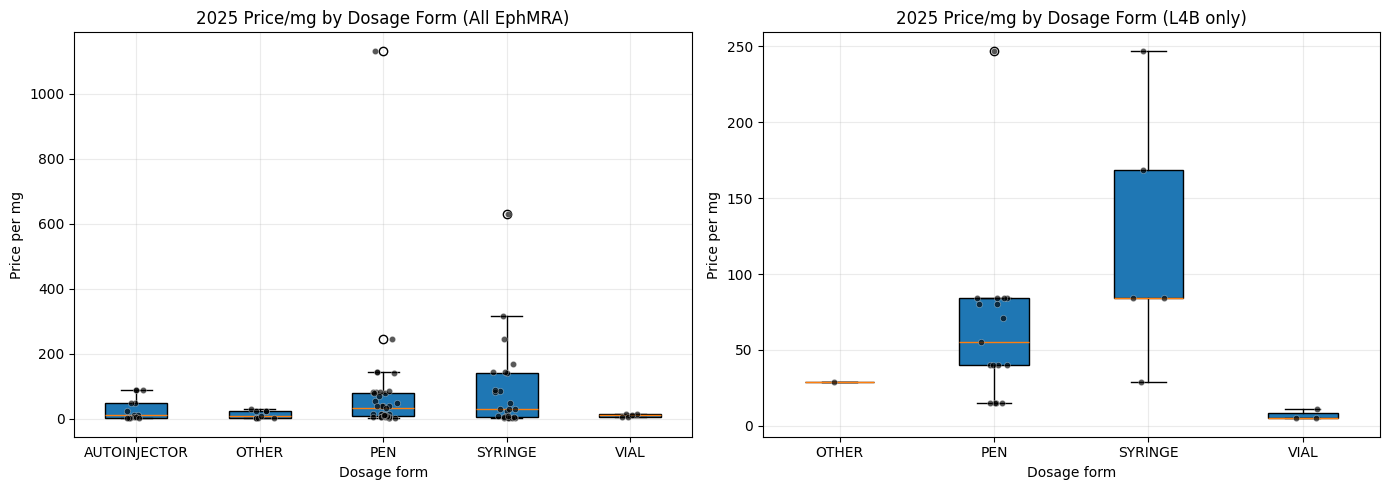

In [9]:
# MODEL 1 box plots (2025-only distributions)
if 'model1_long' in globals() and len(model1_long) > 0:
    plot_df = model1_long[['Corrected EphMRA Code', 'dosage_form', 'price_per_mg']].copy()
    plot_df['is_l4b'] = plot_df['Corrected EphMRA Code'].str.contains(r'\bL4B\b', case=False, regex=True, na=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    def boxplot_with_dots(ax, frame, title):
        forms = sorted(frame['dosage_form'].dropna().unique().tolist())
        groups = [frame.loc[frame['dosage_form'] == form, 'price_per_mg'].values for form in forms]
        ax.boxplot(groups, tick_labels=forms, patch_artist=True)
        for idx, values in enumerate(groups, start=1):
            jitter = np.random.normal(loc=idx, scale=0.05, size=len(values))
            ax.scatter(jitter, values, s=20, alpha=0.65, color='black', edgecolors='white', linewidths=0.3, zorder=3)
        ax.set_title(title)
        ax.set_xlabel('Dosage form')
        ax.set_ylabel('Price per mg')
        ax.grid(alpha=0.25)

    # Box plot A: overall by dosage form
    boxplot_with_dots(axes[0], plot_df, '2025 Price/mg by Dosage Form (All EphMRA)')

    # Box plot B: L4B only by dosage form
    l4b_df = plot_df[plot_df['is_l4b']].copy()
    if len(l4b_df) > 0:
        boxplot_with_dots(axes[1], l4b_df, '2025 Price/mg by Dosage Form (L4B only)')
    else:
        axes[1].text(0.5, 0.5, 'No L4B rows found', ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title('2025 Price/mg by Dosage Form (L4B only)')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Run Model 1 first to create model1_long.')

## Model 2A
Holdout Split method -- trained on 75% of the groups and tested on remaining

In [22]:
# MODEL 2A: Group-aware regression using all row-level values,
# evaluate on held-out groups, then fit on full data for group-wise predictions.
year_cols = ['2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']

# Keep all row-level values, but dedupe exact duplicates
raw_model2 = data_clean[
    ['ndc11', 'Corrected EphMRA Code', 'dosage_form'] + year_cols
]\
    .drop_duplicates(subset=['ndc11', 'Corrected EphMRA Code', 'dosage_form'] + year_cols)\
    .copy()

raw_model2['group_id'] = raw_model2['Corrected EphMRA Code'] + ' (' + raw_model2['dosage_form'] + ')'

# Keep groups that have at least 3 distinct years represented across their rows
group_year_coverage = raw_model2.groupby('group_id')[year_cols].apply(lambda g: g.notna().any().sum())
valid_groups = group_year_coverage[group_year_coverage >= 3].index
model2_source = raw_model2[raw_model2['group_id'].isin(valid_groups)].copy()

print(f"Row-level records kept for model_2: {len(model2_source)}")
print(f"Groups with 3+ years represented: {model2_source['group_id'].nunique()}")

records = []
year_pairs = [
    (2023, '2022_per_mg', '2023_per_mg'),
    (2024, '2023_per_mg', '2024_per_mg'),
    (2025, '2024_per_mg', '2025_per_mg'),
]

for _, row in model2_source.iterrows():
    for target_year, lag_col, target_col in year_pairs:
        lag_price = row[lag_col]
        target_price = row[target_col]
        if pd.notna(lag_price) and pd.notna(target_price):
            records.append({
                'group_id': row['group_id'],
                'ndc11': row['ndc11'],
                'ephmra_code': row['Corrected EphMRA Code'],
                'dosage_form': row['dosage_form'],
                'year': target_year,
                'lag_price_per_mg': lag_price,
                'target_price_per_mg': target_price,
            })

model2_data = pd.DataFrame(records)
print(f"Model 2 candidate rows: {len(model2_data)}")
print(f"Unique groups in model_2: {model2_data['group_id'].nunique()}")
print(f"Unique ndc11 in model_2: {model2_data['ndc11'].nunique()}")

if len(model2_data) < 12 or model2_data['group_id'].nunique() < 6:
    print('Not enough grouped data points for a stable regression evaluation.')
else:
    X2 = model2_data[['ephmra_code', 'dosage_form', 'year', 'lag_price_per_mg']]
    y2 = model2_data['target_price_per_mg']
    groups = model2_data['group_id']

    categorical_features = ['ephmra_code', 'dosage_form']
    numeric_features = ['year', 'lag_price_per_mg']

    # Step 1: Holdout evaluation by group.
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
    train_idx, test_idx = next(splitter.split(X2, y2, groups=groups))

    X2_train, X2_test = X2.iloc[train_idx], X2.iloc[test_idx]
    y2_train, y2_test = y2.iloc[train_idx], y2.iloc[test_idx]

    preprocessor_eval = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features),
        ]
    )

    model2_eval = Pipeline(steps=[
        ('preprocessor', preprocessor_eval),
        ('regressor', LinearRegression()),
    ])

    model2_eval.fit(X2_train, y2_train)
    y2_pred = model2_eval.predict(X2_test)

    r2_model2 = r2_score(y2_test, y2_pred)
    rmse_model2 = np.sqrt(mean_squared_error(y2_test, y2_pred))
    mae_model2 = mean_absolute_error(y2_test, y2_pred)
    mape_model2 = np.mean(np.abs((y2_test - y2_pred) / y2_test)) * 100

    print('\n=== MODEL 2A: Holdout Evaluation (group-based split) ===')
    print(f"Train rows: {len(X2_train)}, Test rows: {len(X2_test)}")
    print(f"Train groups: {model2_data.iloc[train_idx]['group_id'].nunique()}, Test groups: {model2_data.iloc[test_idx]['group_id'].nunique()}")
    print(f"Holdout actual range: ${y2_test.min():.4f} to ${y2_test.max():.4f} per mg")
    print(f"Full target range: ${y2.min():.4f} to ${y2.max():.4f} per mg")
    print(f"R² Score: {r2_model2:.4f}")
    print(f"RMSE: ${rmse_model2:.4f} per mg")
    print(f"MAE: ${mae_model2:.4f} per mg")
    print(f"MAPE: {mape_model2:.2f}%")

    # Optional group-level view of holdout predictions.
    test_eval = model2_data.iloc[test_idx][['group_id']].copy()
    test_eval['actual'] = y2_test.to_numpy()
    test_eval['pred'] = y2_pred
    group_test_eval = test_eval.groupby('group_id', as_index=False).agg(
        n_rows=('actual', 'size'),
        actual_mean=('actual', 'mean'),
        pred_mean=('pred', 'mean'),
    )
    print('\nHoldout group-level mean actual vs predicted (sample):')
    print(group_test_eval.head(12).round(4).to_string(index=False))

    # Step 2: Fit final model on all rows for production group predictions.
    preprocessor_full = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features),
        ]
    )

    model2 = Pipeline(steps=[
        ('preprocessor', preprocessor_full),
        ('regressor', LinearRegression()),
    ])
    model2.fit(X2, y2)

    y2_all = y2.to_numpy(dtype=float)
    y2_pred_all = model2.predict(X2)
    r2_model2_all = r2_score(y2_all, y2_pred_all)
    rmse_model2_all = np.sqrt(mean_squared_error(y2_all, y2_pred_all))
    mae_model2_all = mean_absolute_error(y2_all, y2_pred_all)

    print('\n=== MODEL 2A: Full-data fit (for group prediction coverage) ===')
    print(f"Rows fit: {len(X2)} across {model2_data['group_id'].nunique()} groups")
    print(f"In-sample R²: {r2_model2_all:.4f}")
    print(f"In-sample RMSE: ${rmse_model2_all:.4f} per mg")
    print(f"In-sample MAE: ${mae_model2_all:.4f} per mg")

    # Build group-wise 2026 prediction inputs using observed 2025 prices as lag values.
    latest_year = model2_data['year'].max()
    latest_panel = model2_data[model2_data['year'] == latest_year].copy()
    if len(latest_panel) > 0:
        group_2026 = latest_panel.groupby(
            ['group_id', 'ephmra_code', 'dosage_form'],
            as_index=False,
        ).agg(
            n_rows=('target_price_per_mg', 'size'),
            lag_2025_per_mg=('target_price_per_mg', 'mean'),
        )
        group_2026['year'] = latest_year + 1

        pred_input_2026 = group_2026[
            ['ephmra_code', 'dosage_form', 'year', 'lag_2025_per_mg']
        ].rename(columns={'lag_2025_per_mg': 'lag_price_per_mg'})

        group_2026['pred_2026_per_mg'] = model2.predict(pred_input_2026)

        print('\nGroup-wise 2026 predicted price per mg (Model 2A):')
        print(
            group_2026[
                ['group_id', 'n_rows', 'lag_2025_per_mg', 'pred_2026_per_mg']
            ]
            .sort_values('pred_2026_per_mg', ascending=False)
            .round(4)
            .to_string(index=False)
        )

        print(f"\nEstimated overall average group prediction for 2026: ${group_2026['pred_2026_per_mg'].mean():.4f} per mg")

Row-level records kept for model_2: 51
Groups with 3+ years represented: 12
Model 2 candidate rows: 100
Unique groups in model_2: 12
Unique ndc11 in model_2: 44

=== MODEL 2A: Holdout Evaluation (group-based split) ===
Train rows: 91, Test rows: 9
Train groups: 9, Test groups: 3
Holdout actual range: $1.8194 to $5.9483 per mg
Full target range: $1.5882 to $631.5693 per mg
R² Score: 0.9016
RMSE: $0.5593 per mg
MAE: $0.4742 per mg
MAPE: 18.88%

Holdout group-level mean actual vs predicted (sample):
                                    group_id  n_rows  actual_mean  pred_mean
            C10A4 (PCSK9 Inhibitors) (OTHER)       3       1.9389     1.9454
N2C2 (Antimigraine CGRP Antagonists) (OTHER)       3       1.8978     1.8170
  N2C2 (Antimigraine CGRP Antagonists) (PEN)       3       5.6920     5.5968

=== MODEL 2A: Full-data fit (for group prediction coverage) ===
Rows fit: 100 across 12 groups
In-sample R²: 0.9998
In-sample RMSE: $1.5214 per mg
In-sample MAE: $1.0252 per mg

Group-wise 

In [23]:
# Optional diagnostics: persistence baseline and lag-target relationship
if 'model2_data' in globals() and len(model2_data) > 0:
    corr = model2_data[['lag_price_per_mg', 'target_price_per_mg']].corr().iloc[0, 1]
    baseline_rmse = np.sqrt(mean_squared_error(model2_data['target_price_per_mg'], model2_data['lag_price_per_mg']))
    baseline_mae = mean_absolute_error(model2_data['target_price_per_mg'], model2_data['lag_price_per_mg'])
    print(f"Lag vs target correlation: {corr:.4f}")
    print(f"Persistence baseline RMSE (predict next = last): ${baseline_rmse:.4f} per mg")
    print(f"Persistence baseline MAE: ${baseline_mae:.4f} per mg")

Lag vs target correlation: 0.9998
Persistence baseline RMSE (predict next = last): $6.2459 per mg
Persistence baseline MAE: $2.8131 per mg


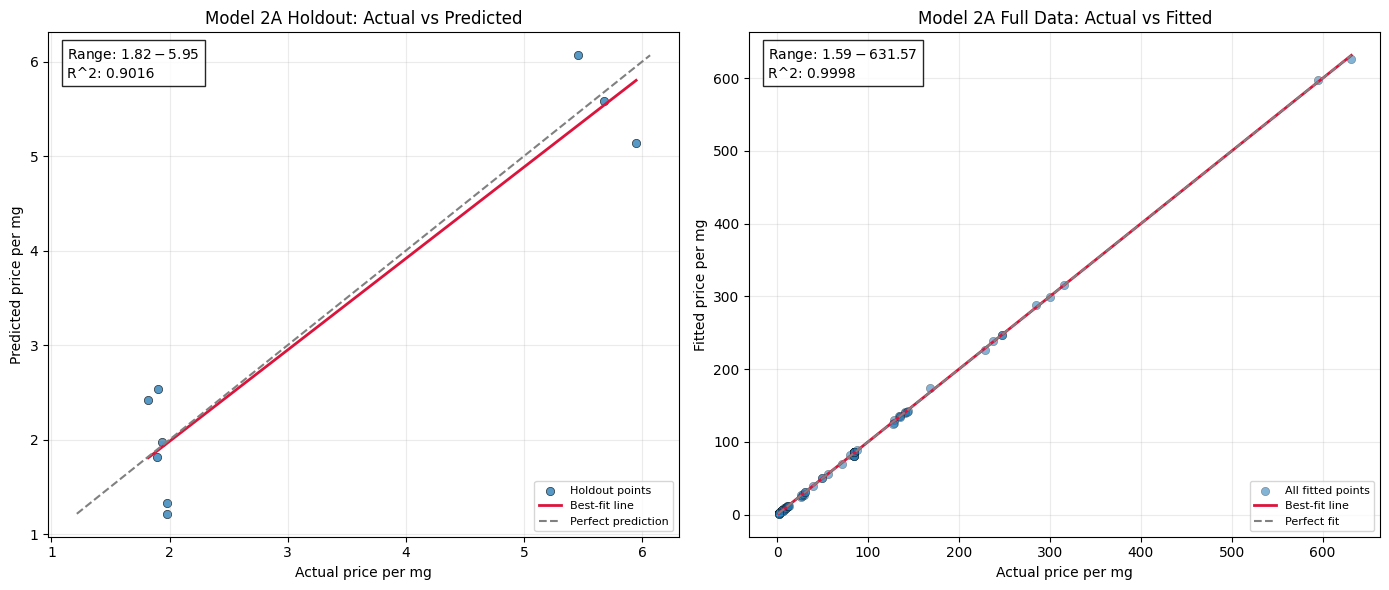

In [24]:
# MODEL 2A visualization: compare holdout-only vs full-data fitted coverage
has_holdout = 'y2_test' in globals() and 'y2_pred' in globals() and len(y2_test) > 1
has_full = 'y2_all' in globals() and 'y2_pred_all' in globals() and len(y2_all) > 1

if has_holdout and has_full:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left panel: holdout (the stricter validation view)
    actual_h = np.asarray(y2_test, dtype=float)
    pred_h = np.asarray(y2_pred, dtype=float)
    m_h, b_h = np.polyfit(actual_h, pred_h, 1)
    xh = np.linspace(actual_h.min(), actual_h.max(), 200)
    yh = m_h * xh + b_h

    axes[0].scatter(actual_h, pred_h, alpha=0.75, edgecolor='black', linewidth=0.5, label='Holdout points')
    axes[0].plot(xh, yh, color='crimson', linewidth=2, label='Best-fit line')
    lim_min_h = min(actual_h.min(), pred_h.min())
    lim_max_h = max(actual_h.max(), pred_h.max())
    axes[0].plot([lim_min_h, lim_max_h], [lim_min_h, lim_max_h], linestyle='--', color='gray', linewidth=1.5, label='Perfect prediction')
    axes[0].set_title('Model 2A Holdout: Actual vs Predicted')
    axes[0].set_xlabel('Actual price per mg')
    axes[0].set_ylabel('Predicted price per mg')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)
    axes[0].text(
        0.03, 0.97,
        f"Range: ${actual_h.min():.2f}-${actual_h.max():.2f}\nR^2: {r2_model2:.4f}",
        transform=axes[0].transAxes,
        fontsize=10,
        va='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='black')
    )

    # Right panel: full-data fit (used for per-group prediction coverage)
    actual_f = np.asarray(y2_all, dtype=float)
    pred_f = np.asarray(y2_pred_all, dtype=float)
    m_f, b_f = np.polyfit(actual_f, pred_f, 1)
    xf = np.linspace(actual_f.min(), actual_f.max(), 200)
    yf = m_f * xf + b_f

    axes[1].scatter(actual_f, pred_f, alpha=0.55, edgecolor='black', linewidth=0.3, label='All fitted points')
    axes[1].plot(xf, yf, color='crimson', linewidth=2, label='Best-fit line')
    lim_min_f = min(actual_f.min(), pred_f.min())
    lim_max_f = max(actual_f.max(), pred_f.max())
    axes[1].plot([lim_min_f, lim_max_f], [lim_min_f, lim_max_f], linestyle='--', color='gray', linewidth=1.5, label='Perfect fit')
    axes[1].set_title('Model 2A Full Data: Actual vs Fitted')
    axes[1].set_xlabel('Actual price per mg')
    axes[1].set_ylabel('Fitted price per mg')
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=8)
    axes[1].text(
        0.03, 0.97,
        f"Range: ${actual_f.min():.2f}-${actual_f.max():.2f}\nR^2: {r2_model2_all:.4f}",
        transform=axes[1].transAxes,
        fontsize=10,
        va='top',
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='black')
    )

    plt.tight_layout()
    plt.show()

elif has_holdout:
    actual = np.asarray(y2_test, dtype=float)
    predicted = np.asarray(y2_pred, dtype=float)
    m, b = np.polyfit(actual, predicted, 1)
    x_line = np.linspace(actual.min(), actual.max(), 200)
    y_line = m * x_line + b

    plt.figure(figsize=(8, 6))
    plt.scatter(actual, predicted, alpha=0.75, edgecolor='black', linewidth=0.5, label='Test points')
    plt.plot(x_line, y_line, color='crimson', linewidth=2, label='Best-fit line')
    lim_min = min(actual.min(), predicted.min())
    lim_max = max(actual.max(), predicted.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--', color='gray', linewidth=1.5, label='Perfect prediction')

    eq_text = f"y = {m:.4f}x + {b:.4f}"
    r2_text = f"R^2 = {r2_model2:.4f}"
    plt.text(0.03, 0.97, f"{eq_text}\n{r2_text}", transform=plt.gca().transAxes,
             fontsize=11, va='top', bbox=dict(facecolor='white', alpha=0.85, edgecolor='black'))

    plt.title('Model 2A Dot Plot: Actual vs Predicted Price per mg (Holdout)')
    plt.xlabel('Actual price per mg')
    plt.ylabel('Predicted price per mg')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Run Model 2A first to create holdout and full-data prediction variables.')

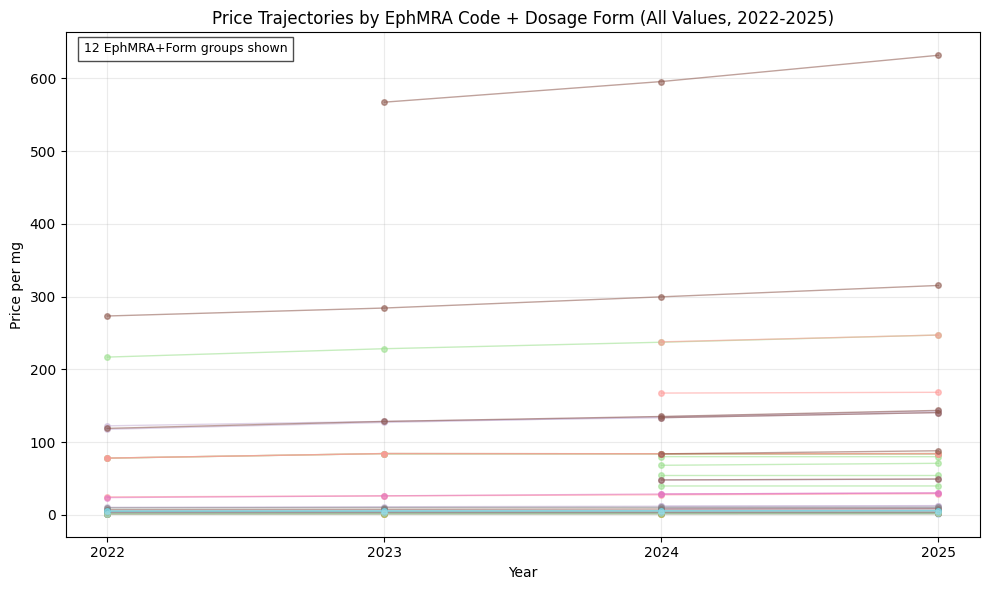

In [25]:
# MODEL 2A: Price trajectories over time by EphMRA + dosage form (all row-level values)
if 'model2_source' in globals() and len(model2_source) > 0:
    traj_df = model2_source[['Corrected EphMRA Code', 'dosage_form', '2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']].copy()
    traj_df = traj_df.dropna(subset=['Corrected EphMRA Code', 'dosage_form']).copy()
    traj_df['group'] = traj_df['Corrected EphMRA Code'] + ' (' + traj_df['dosage_form'] + ')'

    years_cols = ['2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']
    years = [2022, 2023, 2024, 2025]

    plt.figure(figsize=(10, 6))
    unique_groups = sorted(traj_df['group'].unique().tolist())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_groups)))

    for group_idx, group_label in enumerate(unique_groups):
        group_data = traj_df[traj_df['group'] == group_label]
        for _, row in group_data.iterrows():
            prices = [row[col] for col in years_cols]
            valid_mask = [pd.notna(p) for p in prices]
            valid_years = [y for y, v in zip(years, valid_mask) if v]
            valid_prices = [p for p, v in zip(prices, valid_mask) if v]
            if len(valid_prices) >= 2:
                plt.plot(valid_years, valid_prices, marker='o', alpha=0.55, color=colors[group_idx], linewidth=1, markersize=4)

    plt.xlabel('Year')
    plt.ylabel('Price per mg')
    plt.title('Price Trajectories by EphMRA Code + Dosage Form (All Values, 2022-2025)')
    plt.grid(alpha=0.25)
    plt.xticks(years)

    if len(unique_groups) <= 10:
        handles = [plt.Line2D([0], [0], color=colors[i], lw=2) for i in range(len(unique_groups))]
        plt.legend(handles, unique_groups, loc='best', fontsize=8, ncol=2)
    else:
        plt.text(0.02, 0.98, f'{len(unique_groups)} EphMRA+Form groups shown',
                 transform=plt.gca().transAxes, fontsize=9, va='top',
                 bbox=dict(facecolor='white', alpha=0.7))

    plt.tight_layout()
    plt.show()
else:
    print('Run Model 2 first to create model2_source.')

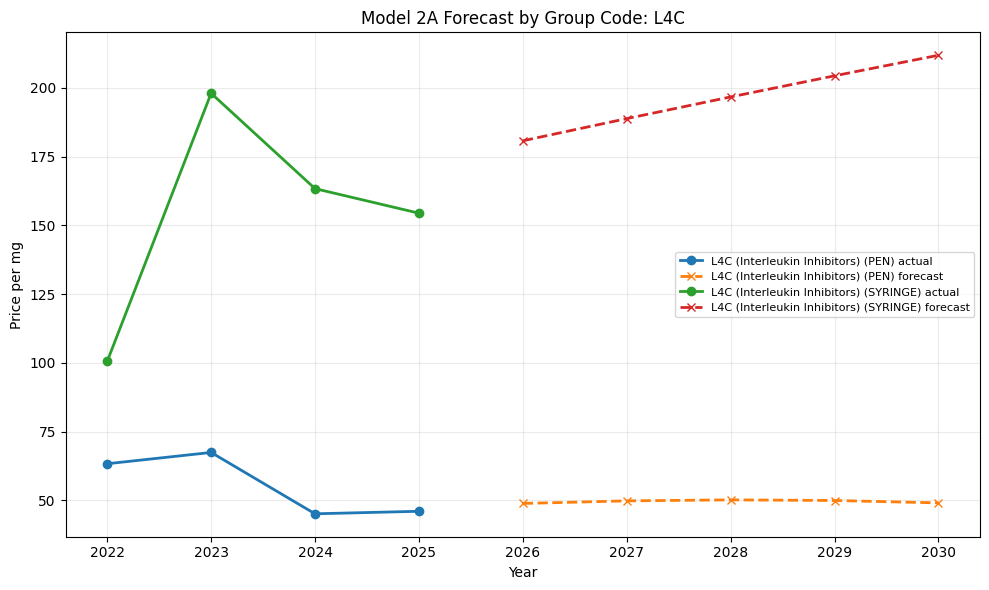

Matched groups for code L4C: 2
Group list: L4C (Interleukin Inhibitors) (PEN), L4C (Interleukin Inhibitors) (SYRINGE)
Forecast horizon shown: 2026 to 2030
Model 2A extrapolation is recursive and uncertainty increases with horizon length.


In [34]:
# MODEL 2A group-specific forecast plot (same pattern as Model 2C)
# User inputs
selected_group_code_2a = 'L4C'   # Example: 'L4C' or 'M5B9'
forecast_end_year_2a = 2030      # Set > 2026 to extrapolate further

if 'model2' not in globals() or 'model2_data' not in globals() or 'model2_source' not in globals():
    print('Run Model 2A first to create model2, model2_data, and model2_source.')
else:
    if forecast_end_year_2a < 2026:
        forecast_end_year_2a = 2026

    # Build historical mean price-by-year for each EphMRA+dosage group.
    hist_2a = model2_source[['group_id', '2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']].copy()
    hist_long_2a = hist_2a.melt(
        id_vars=['group_id'],
        value_vars=['2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg'],
        var_name='year_col',
        value_name='price_per_mg'
    ).dropna(subset=['price_per_mg']).copy()
    hist_long_2a['year'] = hist_long_2a['year_col'].str.extract(r'(\d{4})').astype(int)

    target_code_2a = str(selected_group_code_2a).strip().upper()
    matched_groups_2a = sorted([
        g for g in model2_data['group_id'].unique().tolist()
        if g.upper().startswith(target_code_2a + ' ')
    ])

    if len(matched_groups_2a) == 0:
        available_codes_2a = sorted({g.split(' ')[0] for g in model2_data['group_id'].unique().tolist()})
        print(f"No groups matched code '{target_code_2a}'.")
        print('Available group codes:', ', '.join(available_codes_2a))
    else:
        # Use latest observed year row as the 2026 prediction input anchor.
        latest_year_2a = int(model2_data['year'].max())
        latest_panel_2a = model2_data[model2_data['year'] == latest_year_2a].copy()
        latest_group_2a = latest_panel_2a.groupby(['group_id', 'ephmra_code', 'dosage_form'], as_index=False).agg(
            lag_2025_per_mg=('target_price_per_mg', 'mean')
        )
        latest_group_2a = latest_group_2a[latest_group_2a['group_id'].isin(matched_groups_2a)].copy()

        if len(latest_group_2a) == 0:
            print(f"Matched code '{target_code_2a}', but no latest-year rows were found for forecasting.")
        else:
            forecast_rows_2a = []
            for _, row in latest_group_2a.iterrows():
                group_id = row['group_id']
                ephmra_code = row['ephmra_code']
                dosage_form = row['dosage_form']
                lag_val = float(row['lag_2025_per_mg'])

                # Recursive one-step-ahead forecasts: each next year uses prior prediction as lag.
                for y in range(2026, forecast_end_year_2a + 1):
                    x_next = pd.DataFrame([{
                        'ephmra_code': ephmra_code,
                        'dosage_form': dosage_form,
                        'year': y,
                        'lag_price_per_mg': lag_val,
                    }])
                    pred_val = float(model2.predict(x_next)[0])
                    forecast_rows_2a.append({
                        'group_id': group_id,
                        'year': y,
                        'pred_price_per_mg': pred_val,
                    })
                    lag_val = pred_val

            forecast_df_2a = pd.DataFrame(forecast_rows_2a)

            hist_plot_2a = hist_long_2a[hist_long_2a['group_id'].isin(matched_groups_2a)].copy()
            hist_plot_2a = hist_plot_2a.groupby(['group_id', 'year'], as_index=False)['price_per_mg'].mean()

            plt.figure(figsize=(10, 6))
            for group_id in matched_groups_2a:
                g_hist = hist_plot_2a[hist_plot_2a['group_id'] == group_id].sort_values('year')
                g_fcst = forecast_df_2a[forecast_df_2a['group_id'] == group_id].sort_values('year')

                if len(g_hist) > 0:
                    plt.plot(
                        g_hist['year'],
                        g_hist['price_per_mg'],
                        marker='o',
                        linewidth=2,
                        label=f"{group_id} actual"
                    )

                if len(g_fcst) > 0:
                    plt.plot(
                        g_fcst['year'],
                        g_fcst['pred_price_per_mg'],
                        marker='x',
                        linestyle='--',
                        linewidth=2,
                        label=f"{group_id} forecast"
                    )

            plt.title(f"Model 2A Forecast by Group Code: {target_code_2a}")
            plt.xlabel('Year')
            plt.ylabel('Price per mg')
            plt.grid(alpha=0.25)
            plt.legend(fontsize=8)
            plt.tight_layout()
            plt.show()

            print(f"Matched groups for code {target_code_2a}: {len(matched_groups_2a)}")
            print('Group list:', ', '.join(matched_groups_2a))
            print(f"Forecast horizon shown: 2026 to {forecast_end_year_2a}")
            if forecast_end_year_2a > 2026:
                print('Model 2A extrapolation is recursive and uncertainty increases with horizon length.')

## Model 2B: Linear Line of Best fit modelling
Linear regression model using line of best fit for each group

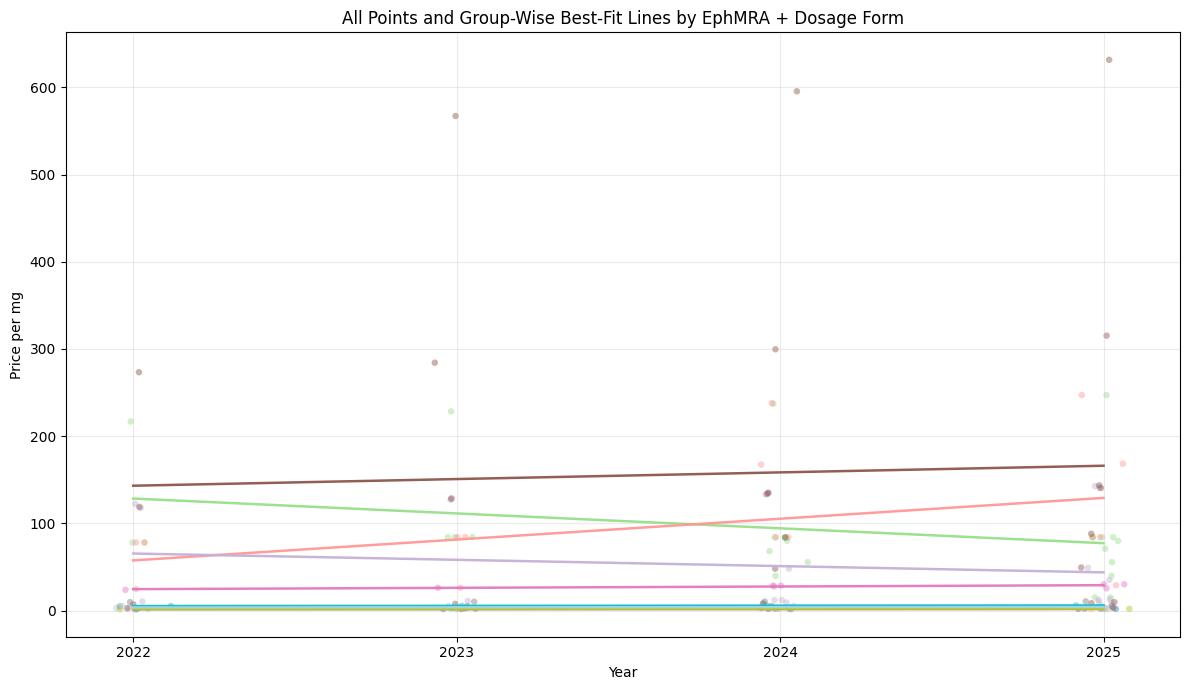

L4B + PEN point counts by year:
year
2022     3
2023     4
2024     9
2025    11


In [26]:
# MODEL 2 comparison plot: all points + group-wise best-fit lines by EphMRA + dosage form
if 'model2_source' in globals() and len(model2_source) > 0:
    traj_df = model2_source[['Corrected EphMRA Code', 'dosage_form', '2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']].copy()
    traj_df = traj_df.dropna(subset=['Corrected EphMRA Code', 'dosage_form']).copy()
    traj_df['group'] = traj_df['Corrected EphMRA Code'] + ' (' + traj_df['dosage_form'] + ')'

    long_traj = traj_df.melt(
        id_vars=['Corrected EphMRA Code', 'dosage_form', 'group'],
        value_vars=['2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg'],
        var_name='year_col',
        value_name='price_per_mg'
    ).dropna(subset=['price_per_mg']).copy()

    long_traj['year'] = long_traj['year_col'].str.extract(r'(\d{4})').astype(int)
    long_traj = long_traj[long_traj['price_per_mg'] > 0].copy()

    plt.figure(figsize=(12, 7))
    rng = np.random.default_rng(42)

    unique_groups = sorted(long_traj['group'].unique().tolist())
    cmap = plt.get_cmap('tab20', len(unique_groups))

    for i, group_label in enumerate(unique_groups):
        g = long_traj[long_traj['group'] == group_label].copy()
        x = g['year'].to_numpy(dtype=float)
        y = g['price_per_mg'].to_numpy(dtype=float)

        # Show every point with slight x-jitter to avoid overplotting
        x_j = x + rng.normal(0, 0.04, size=len(x))
        plt.scatter(x_j, y, s=22, alpha=0.45, color=cmap(i), edgecolor='none')

        # Best-fit line per EphMRA+dosage group
        if len(g) >= 2 and g['year'].nunique() >= 2:
            m_g, b_g = np.polyfit(x, y, 1)
            x_line = np.linspace(2022, 2025, 50)
            y_line = m_g * x_line + b_g
            plt.plot(x_line, y_line, color=cmap(i), linewidth=1.8, alpha=0.95)

    plt.title('All Points and Group-Wise Best-Fit Lines by EphMRA + Dosage Form')
    plt.xlabel('Year')
    plt.ylabel('Price per mg')
    plt.xticks([2022, 2023, 2024, 2025])
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Quick check for your example group
    l4b_pen = long_traj[
        long_traj['Corrected EphMRA Code'].str.contains(r'\bL4B\b', case=False, regex=True, na=False) &
        (long_traj['dosage_form'] == 'PEN')
    ]
    if len(l4b_pen) > 0:
        print('L4B + PEN point counts by year:')
        print(l4b_pen.groupby('year')['price_per_mg'].count().to_string())
else:
    print('Run Model 2 first to create model2_source.')

In [35]:
# MODEL 2B: Group-wise best-fit trend as prediction model
if 'model2_source' in globals() and len(model2_source) > 0:
    trend_df = model2_source[['Corrected EphMRA Code', 'dosage_form', '2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']].copy()
    trend_df['group'] = trend_df['Corrected EphMRA Code'] + ' (' + trend_df['dosage_form'] + ')'

    trend_long = trend_df.melt(
        id_vars=['Corrected EphMRA Code', 'dosage_form', 'group'],
        value_vars=['2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg'],
        var_name='year_col',
        value_name='price_per_mg'
    ).dropna(subset=['price_per_mg']).copy()
    trend_long['year'] = trend_long['year_col'].str.extract(r'(\d{4})').astype(int)
    trend_long = trend_long[trend_long['price_per_mg'] > 0].copy()

    group_models = []
    preds_all = []

    for group_label, g in trend_long.groupby('group'):
        if len(g) >= 3 and g['year'].nunique() >= 2:
            x = g['year'].to_numpy(dtype=float)
            y = g['price_per_mg'].to_numpy(dtype=float)
            slope_g, intercept_g = np.polyfit(x, y, 1)

            y_hat = slope_g * x + intercept_g
            r2_group = r2_score(y, y_hat)
            preds_all.append(pd.DataFrame({'group': group_label, 'actual': y, 'pred': y_hat}))

            pred_2026 = slope_g * 2026 + intercept_g
            group_models.append({
                'group': group_label,
                'n_points': len(g),
                'slope_per_year': slope_g,
                'intercept': intercept_g,
                'r2': r2_group,
                'pred_2026': pred_2026
            })

    if len(group_models) == 0:
        print('Not enough grouped points to fit group-wise trend lines.')
    else:
        model2b_summary = pd.DataFrame(group_models).sort_values('group').reset_index(drop=True)
        pred_frame = pd.concat(preds_all, ignore_index=True)

        model2b_r2 = r2_score(pred_frame['actual'], pred_frame['pred'])
        model2b_rmse = np.sqrt(mean_squared_error(pred_frame['actual'], pred_frame['pred']))
        model2b_mae = mean_absolute_error(pred_frame['actual'], pred_frame['pred'])

        print('=== MODEL 2B: Group-wise Best-Fit Trend Model ===')
        print(f'Groups fitted: {len(model2b_summary)}')
        print(f'Points used: {len(pred_frame)}')
        print(f'In-sample R^2: {model2b_r2:.4f}')
        print(f'In-sample RMSE: ${model2b_rmse:.4f} per mg')
        print(f'In-sample MAE: ${model2b_mae:.4f} per mg')

        print('\nSample of 2026 predictions by EphMRA+dosage group:')
        print(model2b_summary[['group', 'n_points', 'slope_per_year', 'r2', 'pred_2026']].head(12).round(4).to_string(index=False))
else:
    print('Run Model 2 first to create model2_source.')

=== MODEL 2B: Group-wise Best-Fit Trend Model ===
Groups fitted: 12
Points used: 151
In-sample R^2: 0.3006
In-sample RMSE: $86.6840 per mg
In-sample MAE: $45.9873 per mg

Sample of 2026 predictions by EphMRA+dosage group:
                                              group  n_points  slope_per_year     r2  pred_2026
                   C10A4 (PCSK9 Inhibitors) (OTHER)         5          0.0535 0.9239     2.0357
                     C10A4 (PCSK9 Inhibitors) (PEN)         8          0.0640 0.0079     2.5695
                 C10A4 (PCSK9 Inhibitors) (SYRINGE)         5          0.0535 0.9221     2.0313
                      L4B (Anti-TNF Products) (PEN)        27        -17.0632 0.0773    60.2406
                  L4B (Anti-TNF Products) (SYRINGE)        16         23.9036 0.1473   153.1400
                 L4C (Interleukin Inhibitors) (PEN)        25         -7.2022 0.0192    36.6306
             L4C (Interleukin Inhibitors) (SYRINGE)        26          7.6406 0.0019   173.7472
     M5B9 

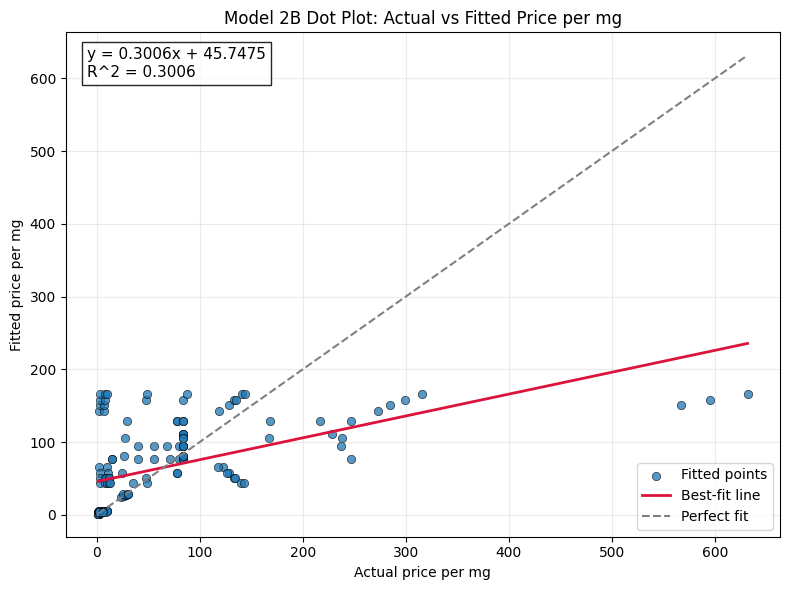


Model 2B sample predictions (top predicted values):
                                         group  n_points  slope_per_year  pred_2026
        L4C (Interleukin Inhibitors) (SYRINGE)        26          7.6406   173.7472
             L4B (Anti-TNF Products) (SYRINGE)        16         23.9036   153.1400
                 L4B (Anti-TNF Products) (PEN)        27        -17.0632    60.2406
            L4C (Interleukin Inhibitors) (PEN)        25         -7.2022    36.6306
M5B9 (Other Bone Calcium Regulators) (SYRINGE)         7          1.5111    30.6410


In [28]:
# MODEL 2B visualization: dot plot with equation/R^2 + simple head() output
if 'pred_frame' in globals() and 'model2b_summary' in globals() and len(pred_frame) > 0:
    actual = pred_frame['actual'].to_numpy(dtype=float)
    fitted = pred_frame['pred'].to_numpy(dtype=float)

    # Fit line on the scatter itself: fitted = m * actual + b
    m_fit, b_fit = np.polyfit(actual, fitted, 1)
    x_line = np.linspace(actual.min(), actual.max(), 200)
    y_line = m_fit * x_line + b_fit

    plt.figure(figsize=(8, 6))
    plt.scatter(actual, fitted, alpha=0.75, edgecolor='black', linewidth=0.5, label='Fitted points')
    plt.plot(x_line, y_line, color='crimson', linewidth=2, label='Best-fit line')

    # Reference line for perfect fit
    lim_min = min(actual.min(), fitted.min())
    lim_max = max(actual.max(), fitted.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle='--', color='gray', linewidth=1.5, label='Perfect fit')

    eq_text = f"y = {m_fit:.4f}x + {b_fit:.4f}"
    r2_text = f"R^2 = {model2b_r2:.4f}"
    plt.text(0.03, 0.97, f"{eq_text}\n{r2_text}", transform=plt.gca().transAxes,
             fontsize=11, va='top', bbox=dict(facecolor='white', alpha=0.85, edgecolor='black'))

    plt.title('Model 2B Dot Plot: Actual vs Fitted Price per mg')
    plt.xlabel('Actual price per mg')
    plt.ylabel('Fitted price per mg')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('\nModel 2B sample predictions (top predicted values):')
    print(
        model2b_summary
        .sort_values('pred_2026', ascending=False)
        [['group', 'n_points', 'slope_per_year', 'pred_2026']]
        .head()
        .round(4)
        .to_string(index=False)
    )
else:
    print('Run Model 2B first to create pred_frame and model2b_summary.')

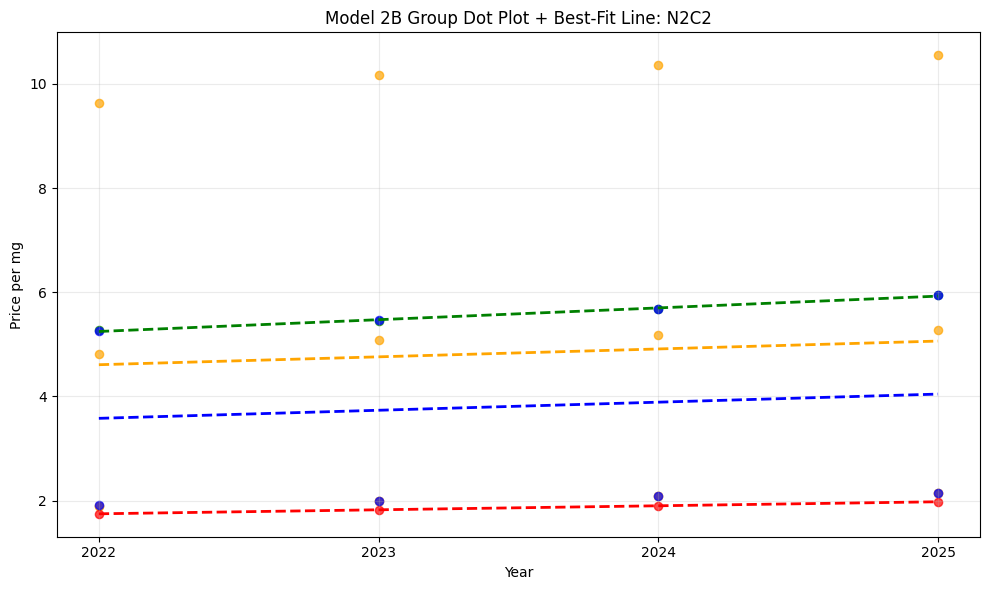

Matched groups for code N2C2: 4
Group list: N2C2 (Antimigraine CGRP Antagonists) (AUTOINJECTOR), N2C2 (Antimigraine CGRP Antagonists) (OTHER), N2C2 (Antimigraine CGRP Antagonists) (PEN), N2C2 (Antimigraine CGRP Antagonists) (SYRINGE)

Plot key: solid circles = actual points, dashed lines = linear best-fit lines
Fixed dosage-form colors: OTHER=Red, PEN=Green, SYRINGE=Blue, AUTOINJECTOR=Orange, VIAL=Yellow

Best-fit equations and R^2 by group (with fixed color names):
                                              group  dosage_form              equation     r2 color_name  n_points
N2C2 (Antimigraine CGRP Antagonists) (AUTOINJECTOR) AUTOINJECTOR y = 0.1513x + -301.42 0.0026     orange        16
       N2C2 (Antimigraine CGRP Antagonists) (OTHER)        OTHER y = 0.0770x + -153.91 0.9972        red         4
         N2C2 (Antimigraine CGRP Antagonists) (PEN)          PEN y = 0.2263x + -452.34 0.9925      green         4
     N2C2 (Antimigraine CGRP Antagonists) (SYRINGE)      SYRINGE y = 

In [42]:
# MODEL 2B group-specific dot plot with best-fit line, formula, and R^2
selected_group_code_2b = 'N2C2'  # Example: 'L4C' or 'M5B9'

if 'model2_source' not in globals() or len(model2_source) == 0:
    print('Run Model 2A first to create model2_source.')
else:
    import matplotlib.colors as mcolors

    # Fixed palette by dosage form for consistent colors across runs and selected codes.
    dosage_color_map = {
        'OTHER': 'red',
        'PEN': 'green',
        'SYRINGE': 'blue',
        'AUTOINJECTOR': 'orange',
        'VIAL': 'yellow',
    }

    group_df_2b = model2_source[
        ['Corrected EphMRA Code', 'dosage_form', '2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']
    ].copy()
    group_df_2b['group'] = group_df_2b['Corrected EphMRA Code'] + ' (' + group_df_2b['dosage_form'] + ')'

    long_2b = group_df_2b.melt(
        id_vars=['Corrected EphMRA Code', 'dosage_form', 'group'],
        value_vars=['2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg'],
        var_name='year_col',
        value_name='price_per_mg'
    ).dropna(subset=['price_per_mg']).copy()

    long_2b['year'] = long_2b['year_col'].str.extract(r'(\d{4})').astype(int)
    long_2b = long_2b[long_2b['price_per_mg'] > 0].copy()

    target_code_2b = str(selected_group_code_2b).strip().upper()
    matched_groups_2b = sorted([
        g for g in long_2b['group'].unique().tolist()
        if g.upper().startswith(target_code_2b + ' ')
    ])

    if len(matched_groups_2b) == 0:
        available_codes_2b = sorted({g.split(' ')[0] for g in long_2b['group'].unique().tolist()})
        print(f"No groups matched code '{target_code_2b}'.")
        print('Available group codes:', ', '.join(available_codes_2b))
    else:
        plt.figure(figsize=(10, 6))
        fit_rows = []

        for group_label in matched_groups_2b:
            g = long_2b[long_2b['group'] == group_label].copy()
            dosage_form_val = str(g['dosage_form'].iloc[0]).upper()
            color_name = dosage_color_map.get(dosage_form_val, 'black')
            group_color = mcolors.to_rgba(color_name)

            x = g['year'].to_numpy(dtype=float)
            y = g['price_per_mg'].to_numpy(dtype=float)

            plt.scatter(x, y, s=35, alpha=0.7, color=group_color)

            if len(g) >= 2 and g['year'].nunique() >= 2:
                m, b = np.polyfit(x, y, 1)
                y_fit = m * x + b
                r2 = r2_score(y, y_fit)

                x_line = np.linspace(x.min(), x.max(), 100)
                y_line = m * x_line + b
                plt.plot(x_line, y_line, linewidth=2, linestyle='--', color=group_color)

                fit_rows.append({
                    'group': group_label,
                    'dosage_form': dosage_form_val,
                    'equation': f"y = {m:.4f}x + {b:.2f}",
                    'r2': round(r2, 4),
                    'color_name': color_name,
                    'n_points': len(g),
                })

        plt.title(f"Model 2B Group Dot Plot + Best-Fit Line: {target_code_2b}")
        plt.xlabel('Year')
        plt.ylabel('Price per mg')
        plt.xticks([2022, 2023, 2024, 2025])
        plt.grid(alpha=0.25)
        plt.tight_layout()
        plt.show()

        print(f"Matched groups for code {target_code_2b}: {len(matched_groups_2b)}")
        print('Group list:', ', '.join(matched_groups_2b))
        print('\nPlot key: solid circles = actual points, dashed lines = linear best-fit lines')
        print('Fixed dosage-form colors: OTHER=Red, PEN=Green, SYRINGE=Blue, AUTOINJECTOR=Orange, VIAL=Yellow')

        if len(fit_rows) > 0:
            fit_summary = pd.DataFrame(fit_rows)
            print('\nBest-fit equations and R^2 by group (with fixed color names):')
            print(fit_summary[['group', 'dosage_form', 'equation', 'r2', 'color_name', 'n_points']].to_string(index=False))

## MODEL 2C: Full-Data Per-Group Forecast Path
This section fits on all available rows and produces group-level forecasts from each group's own lagged history.

In [20]:
# MODEL 2C: Full-data per-group forecast path
if 'model2_data' in globals() and len(model2_data) > 0:
    X2_full = model2_data[['ephmra_code', 'dosage_form', 'year', 'lag_price_per_mg']]
    y2_full = model2_data['target_price_per_mg']
    groups_full = model2_data['group_id']

    categorical_features_2c = ['ephmra_code', 'dosage_form']
    numeric_features_2c = ['year', 'lag_price_per_mg']

    preprocessor_2c = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_2c),
            ('num', 'passthrough', numeric_features_2c),
        ]
    )

    model2c = Pipeline(steps=[
        ('preprocessor', preprocessor_2c),
        ('regressor', LinearRegression()),
    ])
    model2c.fit(X2_full, y2_full)

    y2_full_pred = model2c.predict(X2_full)
    r2_model2c = r2_score(y2_full, y2_full_pred)
    rmse_model2c = np.sqrt(mean_squared_error(y2_full, y2_full_pred))
    mae_model2c = mean_absolute_error(y2_full, y2_full_pred)

    print('=== MODEL 2C: Full-Data Per-Group Forecast Path ===')
    print(f"Rows fit: {len(X2_full)} across {groups_full.nunique()} groups")
    if 'r2_model2' in globals():
        print(f"Model 2A holdout R²: {r2_model2:.4f}")
        print(f"Model 2A holdout RMSE: ${rmse_model2:.4f} per mg")
    if 'r2_model2_all' in globals():
        print(f"Model 2A full-data R²: {r2_model2_all:.4f}")
        print(f"Model 2A full-data RMSE: ${rmse_model2_all:.4f} per mg")
    print(f"Model 2C full-data R²: {r2_model2c:.4f}")
    print(f"Model 2C full-data RMSE: ${rmse_model2c:.4f} per mg")
    print(f"Model 2C full-data MAE: ${mae_model2c:.4f} per mg")

    latest_year_2c = model2_data['year'].max()
    latest_panel_2c = model2_data[model2_data['year'] == latest_year_2c].copy()
    if len(latest_panel_2c) > 0:
        group_2026_2c = latest_panel_2c.groupby(
            ['group_id', 'ephmra_code', 'dosage_form'],
            as_index=False,
        ).agg(
            n_rows=('target_price_per_mg', 'size'),
            lag_2025_per_mg=('target_price_per_mg', 'mean'),
        )
        group_2026_2c['year'] = latest_year_2c + 1

        pred_input_2026_2c = group_2026_2c[
            ['ephmra_code', 'dosage_form', 'year', 'lag_2025_per_mg']
        ].rename(columns={'lag_2025_per_mg': 'lag_price_per_mg'})

        group_2026_2c['pred_2026_per_mg'] = model2c.predict(pred_input_2026_2c)
        group_2026_2c['pct_change_vs_2025'] = (
            (group_2026_2c['pred_2026_per_mg'] - group_2026_2c['lag_2025_per_mg'])
            / group_2026_2c['lag_2025_per_mg']
        ) * 100

        print('\nGroup-wise 2026 predicted price per mg (Model 2C):')
        print(
            group_2026_2c[[
                'group_id', 'n_rows', 'lag_2025_per_mg',
                'pred_2026_per_mg', 'pct_change_vs_2025'
            ]]
            .sort_values('pred_2026_per_mg', ascending=False)
            .round(4)
            .to_string(index=False)
        )
        print(f"\nEstimated overall average group prediction for 2026: ${group_2026_2c['pred_2026_per_mg'].mean():.4f} per mg")
else:
    print('Run Model 2A first to create model2_data.')

=== MODEL 2C: Full-Data Per-Group Forecast Path ===
Rows fit: 100 across 12 groups
Model 2A holdout R²: 0.9016
Model 2A holdout RMSE: $0.5593 per mg
Model 2A full-data R²: 0.9998
Model 2A full-data RMSE: $1.5214 per mg
Model 2C full-data R²: 0.9998
Model 2C full-data RMSE: $1.5214 per mg
Model 2C full-data MAE: $1.0252 per mg

Group-wise 2026 predicted price per mg (Model 2C):
                                           group_id  n_rows  lag_2025_per_mg  pred_2026_per_mg  pct_change_vs_2025
             L4C (Interleukin Inhibitors) (SYRINGE)       8         172.5347          180.7836              4.7810
                  L4B (Anti-TNF Products) (SYRINGE)       5         122.6417          125.6765              2.4745
                      L4B (Anti-TNF Products) (PEN)       9          92.2383           93.5442              1.4157
                 L4C (Interleukin Inhibitors) (PEN)       8          47.3768           48.8499              3.1093
     M5B9 (Other Bone Calcium Regulators) (SY

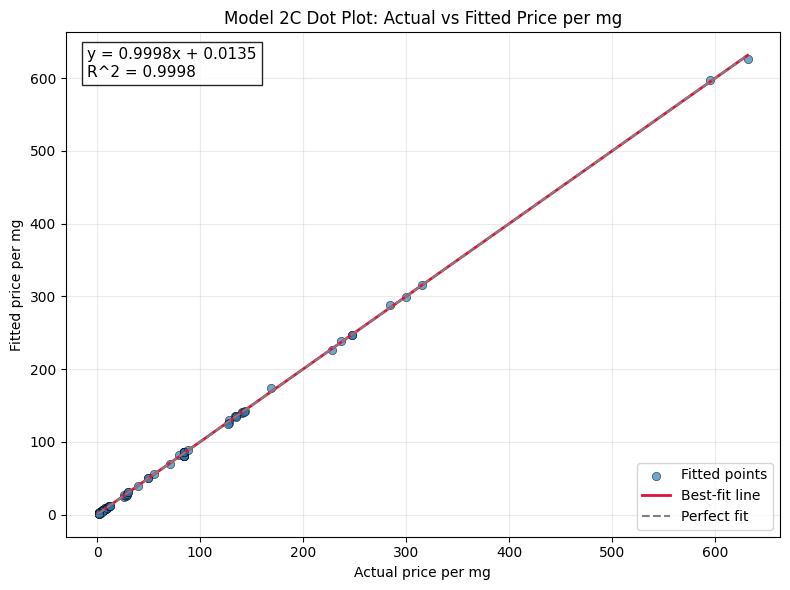

In [21]:
# MODEL 2C visualization: actual vs fitted for the full-data per-group forecast path
if 'y2_full' in globals() and 'y2_full_pred' in globals() and len(y2_full) > 1:
    actual_2c = np.asarray(y2_full, dtype=float)
    fitted_2c = np.asarray(y2_full_pred, dtype=float)

    # Fit line on the scatter itself: fitted = m * actual + b
    m_2c, b_2c = np.polyfit(actual_2c, fitted_2c, 1)
    x_line_2c = np.linspace(actual_2c.min(), actual_2c.max(), 200)
    y_line_2c = m_2c * x_line_2c + b_2c

    plt.figure(figsize=(8, 6))
    plt.scatter(actual_2c, fitted_2c, alpha=0.65, edgecolor='black', linewidth=0.5, label='Fitted points')
    plt.plot(x_line_2c, y_line_2c, color='crimson', linewidth=2, label='Best-fit line')

    # Reference line for perfect fit
    lim_min_2c = min(actual_2c.min(), fitted_2c.min())
    lim_max_2c = max(actual_2c.max(), fitted_2c.max())
    plt.plot([lim_min_2c, lim_max_2c], [lim_min_2c, lim_max_2c], linestyle='--', color='gray', linewidth=1.5, label='Perfect fit')

    eq_text_2c = f"y = {m_2c:.4f}x + {b_2c:.4f}"
    r2_text_2c = f"R^2 = {r2_model2c:.4f}"
    plt.text(0.03, 0.97, f"{eq_text_2c}\n{r2_text_2c}", transform=plt.gca().transAxes,
             fontsize=11, va='top', bbox=dict(facecolor='white', alpha=0.85, edgecolor='black'))

    plt.title('Model 2C Dot Plot: Actual vs Fitted Price per mg')
    plt.xlabel('Actual price per mg')
    plt.ylabel('Fitted price per mg')
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Run Model 2C first to create y2_full and y2_full_pred.')

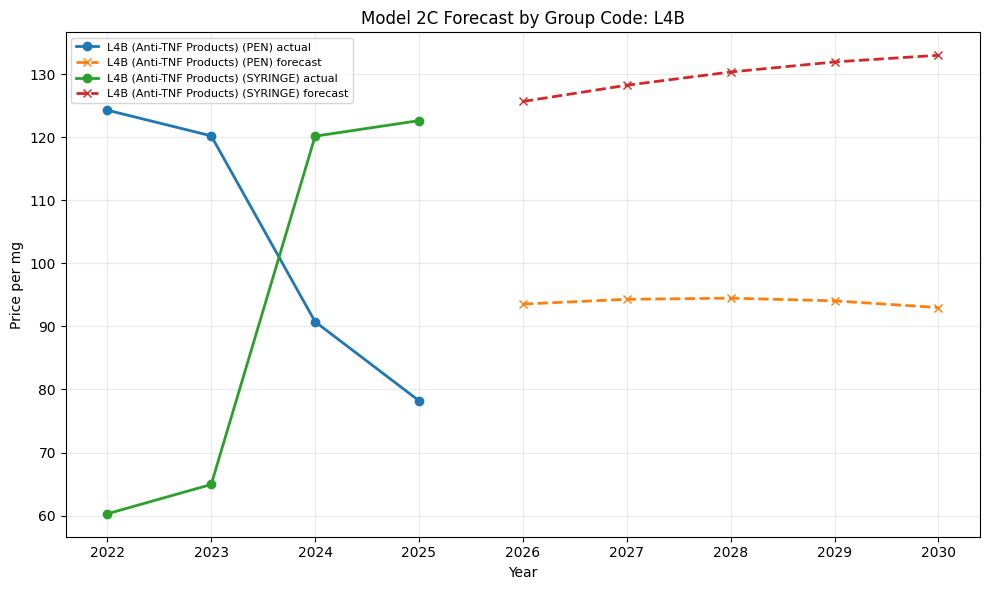

Matched groups for code L4B: 2
Group list: L4B (Anti-TNF Products) (PEN), L4B (Anti-TNF Products) (SYRINGE)
Forecast horizon shown: 2026 to 2030
Yes: Model 2C can extrapolate beyond 2026 by recursively feeding prior predictions as lag inputs.
Caution: uncertainty increases as horizon extends farther from observed data.


In [30]:
# MODEL 2C group-specific forecast plot (supports extrapolation beyond 2026)
# User inputs
selected_group_code = 'L4B'   # Example: 'L4C' or 'M5B9'
forecast_end_year = 2030       # Set > 2026 to extrapolate further

if 'model2c' not in globals() or 'model2_data' not in globals() or 'model2_source' not in globals():
    print('Run Model 2A and Model 2C cells first to create model2_data, model2_source, and model2c.')
else:
    if forecast_end_year < 2026:
        forecast_end_year = 2026

    # Build historical mean price-by-year for each EphMRA+dosage group.
    hist = model2_source[['group_id', '2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg']].copy()
    hist_long = hist.melt(
        id_vars=['group_id'],
        value_vars=['2022_per_mg', '2023_per_mg', '2024_per_mg', '2025_per_mg'],
        var_name='year_col',
        value_name='price_per_mg'
    ).dropna(subset=['price_per_mg']).copy()
    hist_long['year'] = hist_long['year_col'].str.extract(r'(\d{4})').astype(int)

    target_code = str(selected_group_code).strip().upper()
    matched_groups = sorted([
        g for g in model2_data['group_id'].unique().tolist()
        if g.upper().startswith(target_code + ' ')
    ])

    if len(matched_groups) == 0:
        available_codes = sorted({g.split(' ')[0] for g in model2_data['group_id'].unique().tolist()})
        print(f"No groups matched code '{target_code}'.")
        print('Available group codes:', ', '.join(available_codes))
    else:
        # Use latest observed year row as the 2026 prediction input anchor.
        latest_year = int(model2_data['year'].max())
        latest_panel = model2_data[model2_data['year'] == latest_year].copy()
        latest_group = latest_panel.groupby(['group_id', 'ephmra_code', 'dosage_form'], as_index=False).agg(
            lag_2025_per_mg=('target_price_per_mg', 'mean')
        )
        latest_group = latest_group[latest_group['group_id'].isin(matched_groups)].copy()

        if len(latest_group) == 0:
            print(f"Matched code '{target_code}', but no latest-year rows were found for forecasting.")
        else:
            forecast_rows = []
            for _, row in latest_group.iterrows():
                group_id = row['group_id']
                ephmra_code = row['ephmra_code']
                dosage_form = row['dosage_form']
                lag_val = float(row['lag_2025_per_mg'])

                # Recursive one-step-ahead forecasts: each next year uses prior prediction as lag.
                for y in range(2026, forecast_end_year + 1):
                    x_next = pd.DataFrame([{
                        'ephmra_code': ephmra_code,
                        'dosage_form': dosage_form,
                        'year': y,
                        'lag_price_per_mg': lag_val,
                    }])
                    pred_val = float(model2c.predict(x_next)[0])
                    forecast_rows.append({
                        'group_id': group_id,
                        'year': y,
                        'pred_price_per_mg': pred_val,
                    })
                    lag_val = pred_val

            forecast_df = pd.DataFrame(forecast_rows)

            hist_plot = hist_long[hist_long['group_id'].isin(matched_groups)].copy()
            hist_plot = hist_plot.groupby(['group_id', 'year'], as_index=False)['price_per_mg'].mean()

            plt.figure(figsize=(10, 6))
            for group_id in matched_groups:
                g_hist = hist_plot[hist_plot['group_id'] == group_id].sort_values('year')
                g_fcst = forecast_df[forecast_df['group_id'] == group_id].sort_values('year')

                if len(g_hist) > 0:
                    plt.plot(
                        g_hist['year'],
                        g_hist['price_per_mg'],
                        marker='o',
                        linewidth=2,
                        label=f"{group_id} actual"
                    )

                if len(g_fcst) > 0:
                    plt.plot(
                        g_fcst['year'],
                        g_fcst['pred_price_per_mg'],
                        marker='x',
                        linestyle='--',
                        linewidth=2,
                        label=f"{group_id} forecast"
                    )

            plt.title(f"Model 2C Forecast by Group Code: {target_code}")
            plt.xlabel('Year')
            plt.ylabel('Price per mg')
            plt.grid(alpha=0.25)
            plt.legend(fontsize=8)
            plt.tight_layout()
            plt.show()

            print(f"Matched groups for code {target_code}: {len(matched_groups)}")
            print('Group list:', ', '.join(matched_groups))
            print(f"Forecast horizon shown: 2026 to {forecast_end_year}")
            if forecast_end_year > 2026:
                print('Yes: Model 2C can extrapolate beyond 2026 by recursively feeding prior predictions as lag inputs.')
                print('Caution: uncertainty increases as horizon extends farther from observed data.')